In [2]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [3]:
#load processed data

df = pd.read_csv("../data/processed/processed_walmart_sales.csv")

In [4]:
df.head()

df.shape

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 382955 entries, 0 to 382954
Data columns (total 47 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Store                       382955 non-null  int64  
 1   Dept                        382955 non-null  int64  
 2   Date                        382955 non-null  str    
 3   Weekly_Sales                382955 non-null  float64
 4   IsHoliday                   382955 non-null  int64  
 5   Size                        382955 non-null  int64  
 6   Temperature                 382955 non-null  float64
 7   Fuel_Price                  382955 non-null  float64
 8   MarkDown1                   382955 non-null  float64
 9   MarkDown2                   382955 non-null  float64
 10  MarkDown3                   382955 non-null  float64
 11  MarkDown4                   382955 non-null  float64
 12  MarkDown5                   382955 non-null  float64
 13  CPI                      

In [5]:
#convert date

df["Date"] = pd.to_datetime(df["Date"])

In [6]:
#time based train test split

train = df[df["Date"] < "2012-01-01"]

test = df[df["Date"] >= "2012-01-01"]

In [7]:
print(train.shape)

print(test.shape)

(256034, 47)
(126921, 47)


In [8]:
# select features 

y_train = train["Weekly_Sales"]

y_test = test["Weekly_Sales"]

In [9]:
X_train = train.drop(
    ["Weekly_Sales","Date"],
    axis=1
)

X_test = test.drop(
    ["Weekly_Sales","Date"],
    axis=1
)

In [10]:
X_train.columns

Index(['Store', 'Dept', 'IsHoliday', 'Size', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Year', 'Month', 'Quarter', 'WeekOfYear', 'DayOfWeek',
       'DayOfMonth', 'Month_Sin', 'Month_Cos', 'Week_Sin', 'Week_Cos',
       'Sales_Lag_1', 'Sales_Lag_2', 'Sales_Lag_4', 'Sales_Lag_8',
       'Sales_Lag_12', 'Rolling_Mean', 'Rolling_Mean_4', 'Rolling_Mean_8',
       'Rolling_Std_4', 'Historical_Avg_Sales', 'Has_Markdown',
       'Total_Markdown', 'Type_A', 'Type_B', 'Type_C', 'Season_Autumn',
       'Season_Spring', 'Season_Summer', 'Season_Winter',
       'Store_Size_Category_Small', 'Store_Size_Category_Medium',
       'Store_Size_Category_Large'],
      dtype='str')

In [11]:
#baseline model

baseline_pred = test["Sales_Lag_1"]

In [12]:
mae = mean_absolute_error(
    y_test,
    baseline_pred
)

print(mae)

1723.4153434813782


In [13]:
#linear regression 

lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

In [14]:
#evaluate
print(
    mean_absolute_error(
        y_test,
        lr_pred
    )
)

4.3404404256760915e-07


In [17]:
#random forest

rf = RandomForestRegressor(
    n_estimators=30,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    max_samples=0.7,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Train model
rf.fit(X_train, y_train)

# Make predictions
rf_pred = rf.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:    1.8s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  30 out of  30 | elapsed:    0.0s finished


In [18]:
#xgboost

xgb = XGBRegressor(

    n_estimators=500,

    learning_rate=0.05,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

In [19]:
#evaluation function

def evaluate_model(
    name,
    actual,
    prediction
):

    mae = mean_absolute_error(
        actual,
        prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            prediction
        )
    )

    r2 = r2_score(
        actual,
        prediction
    )

    mape = np.mean(
        np.abs(
            (actual-prediction)/actual
        )
    )*100

    return [
        name,
        mae,
        rmse,
        mape,
        r2
    ]

In [20]:
#compare models

#create
results = []

#append
results.append(
    evaluate_model(
        "Baseline",
        y_test,
        baseline_pred
    )
)

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    )
)

#convert
results = pd.DataFrame(

    results,

    columns=[

        "Model",

        "MAE",

        "RMSE",

        "MAPE",

        "R2"

    ]

)

results

,Model,MAE,RMSE,MAPE,R2
0,Baseline,1.723415e+03,3.948273e+03,inf,0.968206
1,Linear Regression,4.340440e-07,5.885518e-07,inf,1.000000
2,Random Forest,1.376388e+03,2.939422e+03,inf,0.982378
3,XGBoost,7.365848e+02,1.730217e+03,inf,0.993894


In [21]:
#feature importance

importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":xgb.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

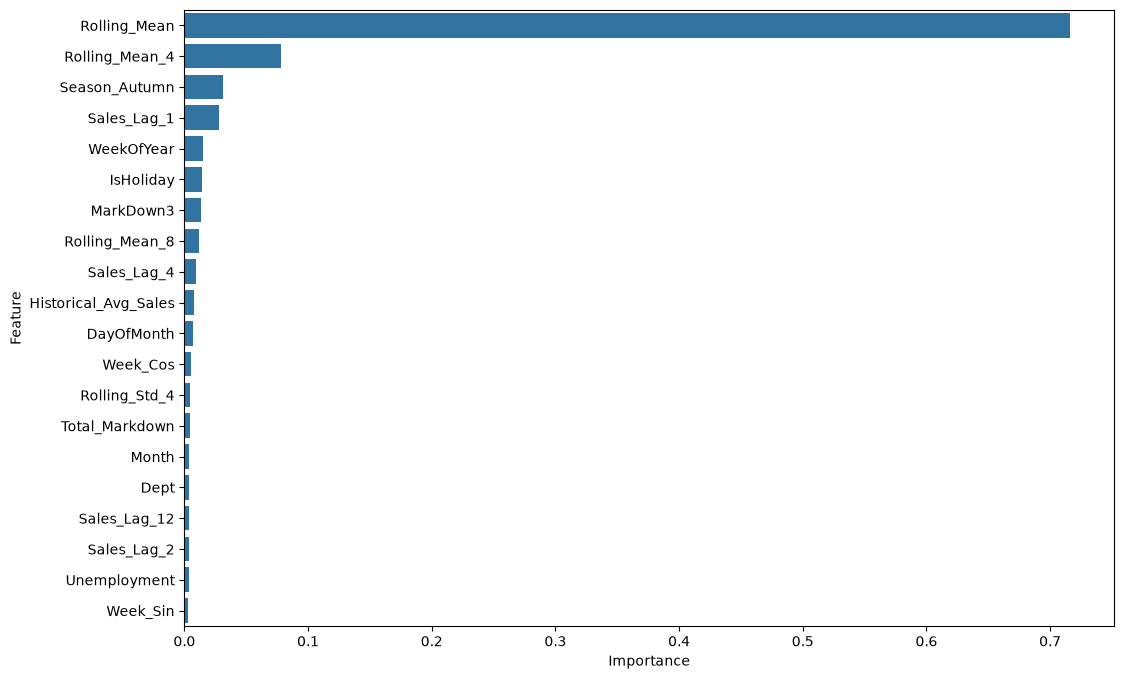

In [22]:
plt.figure(figsize=(12,8))

sns.barplot(

    data=importance.head(20),

    y="Feature",

    x="Importance"

)

plt.show()

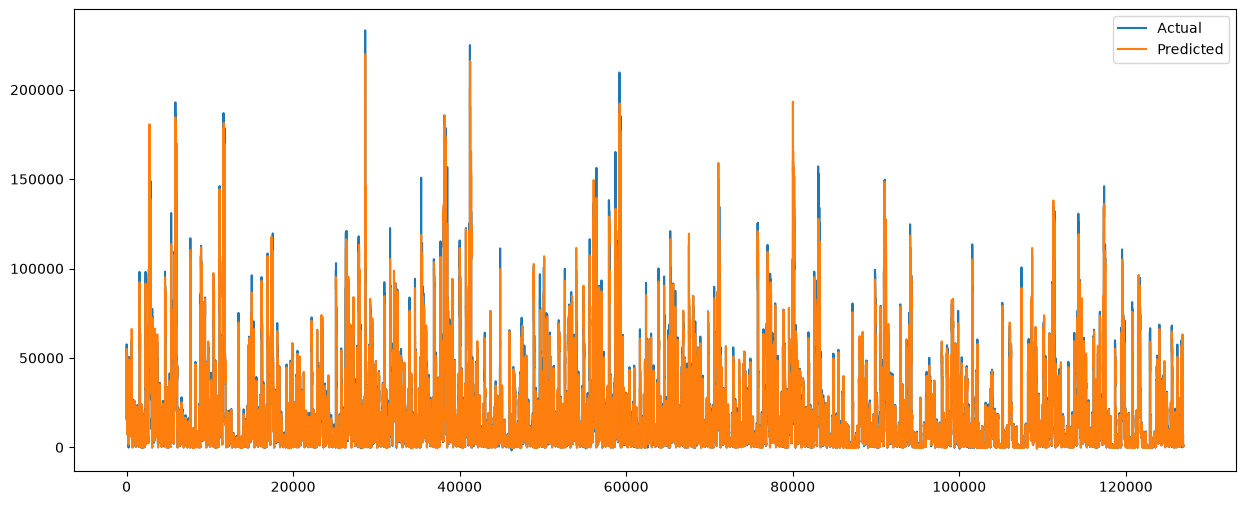

In [23]:
#actual vs predicted

plt.figure(

    figsize=(15,6)

)

plt.plot(

    y_test.values,

    label="Actual"

)

plt.plot(

    xgb_pred,

    label="Predicted"

)

plt.legend()

plt.show()

<Axes: xlabel='Weekly_Sales', ylabel='Count'>

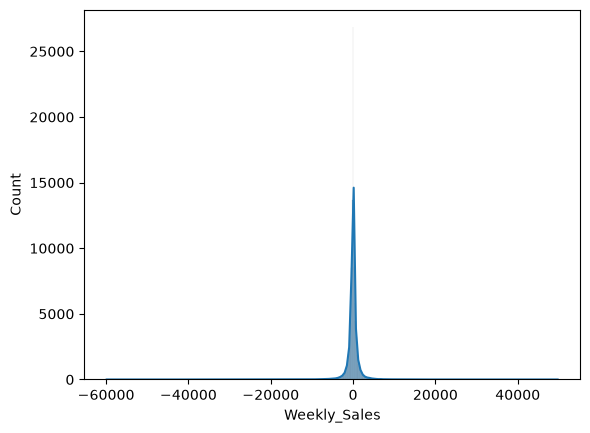

In [24]:
#residual plot

residual = y_test - xgb_pred

sns.histplot(
    residual,
    kde=True
)

In [25]:
#save model

joblib.dump(

    xgb,

    "../models/xgb_model.pkl"

)

['../models/xgb_model.pkl']

In [26]:
joblib.dump(

    X_train.columns,

    "../models/features.pkl"

)
#will be used in FASTAPI

['../models/features.pkl']

In [27]:
#test saved model

model = joblib.load(

    "../models/xgb_model.pkl"

)

In [28]:
model.predict(
    X_test.iloc[:5]
)

array([20490.162, 16423.746, 17868.105, 18029.432, 22986.436],
      dtype=float32)

In [29]:
#save results

results.to_csv(

    "../models/model_results.csv",

    index=False

)